## 00. load package

In [78]:

import intake
import cartopy.crs as ccrs
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import easygems.healpix as egh
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from typing import Tuple, List, Optional, Union, Dict
import scipy.signal as signal
from global_land_mask import globe
import math
import time
import os
import pickle
from scipy import fft
import cmaps  
from typing import Optional
import sys
import matplotlib.colors as mcolors
import importlib
sys.path.append("/home/m/m301257/wave_tools")
from wave_tools.utils import dataarray_to_equatorial_latlon_grid,get_region_healpix_,create_cmap_from_string,dataarray_healpix_to_equatorial_latlon
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
import wave_tools.plotting
importlib.reload(wave_tools.spectral)
importlib.reload(wave_tools.plotting)
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)
import mpi4py
import logging
import glob
import gc
DATA_DIR = "./processed_data"
os.makedirs(DATA_DIR, exist_ok=True)
fig_save_dir = "./figures/Cal_MSE/"
os.makedirs(fig_save_dir, exist_ok=True)
print("="*70)
print(f"📁 数据保存目录: {DATA_DIR}")
print(f"📁 图形保存目录: {fig_save_dir}")

✅ 模块重新加载完成
📁 数据保存目录: ./processed_data
📁 图形保存目录: ./figures/Cal_MSE/


In [79]:
# 网格转换参数

def dataarray_to_equatorial_latlon_grid(
    dataarray: xr.DataArray, grid_type: str, grid_dict: Optional[dict]
) -> xr.DataArray:
    """转换数据到赤道经纬度网格"""
    if grid_type == "latlon":
        return dataarray
    elif grid_type == "healpix":
        if grid_dict is None:
            raise ValueError("No grid_dict provided for healpix conversion.")
        return dataarray_healpix_to_equatorial_latlon(dataarray, **grid_dict)
    else:
        raise ValueError("Grid type not found.")




In [80]:
def load_or_process_data(experiment_name, dataset_key, save_path, grid_dict, target_lat, target_lon):
    """
    加载已保存的插值数据，或者处理原始数据并保存
    
    Parameters:
    -----------
    experiment_name : str
        实验名称（用于显示）
    dataset_key : str
        在catalog中的数据集键名
    save_path : str
        保存路径
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
        
    Returns:
    --------
    xr.DataArray : 插值后的数据
    """
    print("="*70)
    print(f"🔄 处理 {experiment_name} 数据...")
    print("="*70)
    
    # 检查是否已存在插值数据
    if os.path.exists(save_path):
        print(f"✅ 发现已保存的插值数据: {save_path}")
        print(f"   正在加载...")
        data_2deg = xr.open_dataarray(save_path)
        print(f"   加载完成! 形状: {data_2deg.shape}")
        return data_2deg
    
    # 如果不存在，则进行处理
    print(f"⚠️  未找到保存的数据，开始处理原始数据...")
    
    # 加载原始数据
    print(f"   1/3 加载原始数据...")
    pr_full = cat.ICON.C5[dataset_key].to_dask()['pr'].sel(time=slice("1980", "1993"))
    print(f"       原始数据形状: {pr_full.shape}")
    
    # 转换到经纬度网格
    print(f"   2/3 转换到经纬度网格...")
    pr_lon_lat = dataarray_to_equatorial_latlon_grid(pr_full, 'healpix', grid_dict)
    print(f"       转换后形状: {pr_lon_lat.shape}")
    
    # 插值到2°x2°
    print(f"   3/3 插值到2°x2°分辨率...")
    data_2deg = pr_lon_lat.interp(lat=target_lat, lon=target_lon, method='linear')
    print(f"       插值后形状: {data_2deg.shape}")
    
    # 保存数据
    print(f"   💾 保存插值数据到: {save_path}")
    data_2deg.to_netcdf(save_path)
    print(f"   ✅ 保存完成!")
    
    return data_2deg

# 设置网格参数（与之前保持一致）
grid_dict = {"nside": 256, "nest": True, "minmax_lat": 16}
target_lat = np.arange(-14, 14.1, 2.0)
target_lon = np.arange(0, 360, 2.0)

print("\n" + "="*70)
print("开始处理三个实验的数据...")
print("="*70)


开始处理三个实验的数据...


In [81]:
pwd

'/work/mh1498/m301257'

In [82]:
def process_var_data(var_name, experiment_name, dataset_key, save_dir, grid_dict, target_lat, target_lon, 
                     has_level=True, level_slice=(30, None)):
    """
    处理变量数据（支持3D和2D），转换网格并插值后保存
    
    Parameters:
    -----------
    var_name : str
        变量名 ('wa', 'hus', 'ta', 'pr')
    experiment_name : str
        实验名称（用于显示）
    dataset_key : str
        在catalog中的数据集键名
    save_dir : str
        保存目录
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
    has_level : bool
        是否为3D数据（有level维度）。True=3D，False=2D
    level_slice : tuple
        level切片范围，仅当has_level=True时有效
    """
    import time
    
    data_type = "3D (多层级)" if has_level else "2D (时间序列)"
    print("="*70)
    print(f"🔄 处理 {var_name.upper()} - {experiment_name} [{data_type}]")
    print("="*70)
    
    # 创建变量和实验的子目录
    if has_level:
        exp_save_dir = os.path.join(save_dir, f"{var_name}_{experiment_name.lower()}_layers")
    else:
        exp_save_dir = os.path.join(save_dir, f"{var_name}_{experiment_name.lower()}")
    os.makedirs(exp_save_dir, exist_ok=True)
    print(f"📁 保存路径: {exp_save_dir}")
    
    # 加载数据（只读取元数据）
    print(f"📖 读取数据元信息...")
    
    if has_level:
        # 3D数据：需要选择level范围
        var_full = cat.ICON.C5[dataset_key].to_dask()[var_name].sel(
            time=slice("1980", "1993"),
            level_full=slice(*level_slice)
        )
        levels = var_full.level_full.values
        n_levels = len(levels)
        
        print(f"✅ 数据信息:")
        print(f"   变量: {var_name}")
        print(f"   时间范围: 1980-1993")
        print(f"   总层数: {n_levels}")
        print(f"   层级范围: {levels[0]:.1f} - {levels[-1]:.1f}")
        print(f"   时间步数: {len(var_full.time)}")
    else:
        # 2D数据：只有时间维度
        var_full = cat.ICON.C5[dataset_key].to_dask()[var_name].sel(
            time=slice("1980", "1993")
        )
        
        print(f"✅ 数据信息:")
        print(f"   变量: {var_name}")
        print(f"   时间范围: 1980-1993")
        print(f"   时间步数: {len(var_full.time)}")
    
    print("="*70)
    
    # 逐层处理（3D）或整体处理（2D）
    total_start_time = time.time()
    
    if has_level:
        # ========== 3D数据：逐层处理 ==========
        for idx, level in enumerate(levels, 1):
            layer_start_time = time.time()
            
            # 构建保存路径
            save_path = os.path.join(exp_save_dir, f"{var_name}_lev_{int(level):03d}.nc")
            
            # 检查是否已处理
            if os.path.exists(save_path):
                print(f"✅ [{idx}/{n_levels}] Level {int(level):3d} - 已存在，跳过")
                continue
            
            print(f"🔄 [{idx}/{n_levels}] 处理 Level {int(level):3d}...")
            
            try:
                # 1. 选择单层数据
                var_layer = var_full.sel(level_full=level)
                print(f"   ├─ 选择层级完成")
                
                # 2. 转换到经纬度网格
                var_lonlat = dataarray_to_equatorial_latlon_grid(var_layer, 'healpix', grid_dict)
                print(f"   ├─ 网格转换完成: {var_lonlat.shape}")
                
                # 3. 插值到2°x2°
                var_2deg = var_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
                print(f"   ├─ 插值完成: {var_2deg.shape}")
                
                # 4. 转换为Dataset并设置变量名，然后保存
                ds_to_save = var_2deg.to_dataset(name=var_name)
                ds_to_save.to_netcdf(save_path)
                
                # 计算时间
                layer_time = time.time() - layer_start_time
                elapsed_time = time.time() - total_start_time
                avg_time_per_layer = elapsed_time / idx
                remaining_layers = n_levels - idx
                estimated_remaining = avg_time_per_layer * remaining_layers
                
                print(f"   ✅ 保存完成: {os.path.basename(save_path)}")
                print(f"   ⏱️  本层耗时: {layer_time:.1f}s | 平均: {avg_time_per_layer:.1f}s/层")
                print(f"   📊 预计剩余时间: {estimated_remaining/60:.1f} 分钟")
                print()
                
            except Exception as e:
                print(f"   ❌ 处理失败: {str(e)}")
                continue
    
    else:
        # ========== 2D数据：整体处理 ==========
        save_path = os.path.join(exp_save_dir, f"{var_name}_2deg_interp.nc")
        
        # 检查是否已处理
        if os.path.exists(save_path):
            print(f"✅ 数据已存在，跳过处理")
            print(f"   文件: {save_path}")
        else:
            print(f"🔄 开始处理2D数据...")
            
            try:
                # 1. 转换到经纬度网格
                print(f"   ├─ 网格转换中...")
                var_lonlat = dataarray_to_equatorial_latlon_grid(var_full, 'healpix', grid_dict)
                print(f"   ├─ 网格转换完成: {var_lonlat.shape}")
                
                # 2. 插值到2°x2°
                print(f"   ├─ 插值中...")
                var_2deg = var_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
                print(f"   ├─ 插值完成: {var_2deg.shape}")
                
                # 3. 转换为Dataset并设置变量名，然后保存
                print(f"   ├─ 保存中...")
                ds_to_save = var_2deg.to_dataset(name=var_name)
                ds_to_save.to_netcdf(save_path)
                
                total_time = time.time() - total_start_time
                print(f"   ✅ 保存完成: {os.path.basename(save_path)}")
                print(f"   ⏱️  总耗时: {total_time/60:.1f} 分钟")
                
            except Exception as e:
                print(f"   ❌ 处理失败: {str(e)}")
    
    total_time = time.time() - total_start_time
    print("="*70)
    print(f"✅ {var_name.upper()} - {experiment_name} 处理完成!")
    print(f"   总耗时: {total_time/60:.1f} 分钟")
    print(f"   保存目录: {exp_save_dir}")
    print("="*70)
    print()


## 步骤2: 计算湿静能(MSE)

In [83]:
# 内存优化版本的MSE计算函数
def calculate_mse_optimized(ta_path, hus_path, zg_2deg, output_path, chunks={'time': 100}):
    """
    计算湿静能 MSE = Cp*T + g*z + L*q (内存优化版本)

    使用dask chunks避免一次性加载所有数据到内存
    """
    import numpy as np
    import gc

    print("="*70)
    print(f"🔄 计算MSE (优化版): {os.path.basename(output_path)}")
    print("="*70)

    # 检查是否已存在
    if os.path.exists(output_path):
        print(f"✅ MSE文件已存在: {output_path}")
        try:
            mse = xr.open_dataarray(output_path, chunks=chunks)
            print(f"   形状: {mse.shape}")
            return mse
        except Exception as open_error:
            print(f"   ❌ 文件损坏: {str(open_error)}")
            print(f"   🔄 删除损坏文件，重新计算...")
            os.remove(output_path)

    # 物理常数
    Cp = 1004.0      # J/(kg·K) - 定压比热
    g = 9.81         # m/s² - 重力加速度
    L = 2.5e6        # J/kg - 蒸发潜热

    print("📖 加载数据（使用chunking）...")
    # 使用chunks参数分块加载，避免一次性加载全部数据
    ta = xr.open_dataarray(ta_path, chunks=chunks)
    hus = xr.open_dataarray(hus_path, chunks=chunks)
    
    print(f"   ta形状: {ta.shape}, 维度: {ta.dims}")
    print(f"   hus形状: {hus.shape}, 维度: {hus.dims}")
    print(f"   zg形状: {zg_2deg.shape}, 维度: {zg_2deg.dims}")
    
    # 重新排列维度顺序为 (time, level, lat, lon)
    print("🔧 调整维度顺序...")
    if ta.dims != ('time', 'level', 'lat', 'lon'):
        print(f"   ta维度从 {ta.dims} 调整为 (time, level, lat, lon)")
        ta = ta.transpose('time', 'level', 'lat', 'lon')
    
    if hus.dims != ('time', 'level', 'lat', 'lon'):
        print(f"   hus维度从 {hus.dims} 调整为 (time, level, lat, lon)")
        hus = hus.transpose('time', 'level', 'lat', 'lon')
    
    print(f"   调整后 - ta形状: {ta.shape}, hus形状: {hus.shape}")
    
    # 确保zg_2deg可以正确广播 - 添加time维度
    print("🔧 准备zg数据广播...")
    if 'time' not in zg_2deg.dims:
        # 如果zg没有time维度，需要广播
        zg_expanded = zg_2deg.expand_dims(time=ta.time, axis=0)
        print(f"   zg广播后形状: {zg_expanded.shape}")
    else:
        zg_expanded = zg_2deg
        print(f"   zg已有time维度: {zg_expanded.shape}")
    
    # 确保level坐标名一致
    if 'level_full' in zg_expanded.dims and 'level' in ta.dims:
        print("🔧 统一level坐标名...")
        zg_expanded = zg_expanded.rename({'level_full': 'level'})
        print("   zg level_full → level")
    
    print(f"   最终维度检查:")
    print(f"   ta: {ta.dims} - {ta.shape}")
    print(f"   hus: {hus.dims} - {hus.shape}")
    print(f"   zg: {zg_expanded.dims} - {zg_expanded.shape}")
    print("🧮 计算MSE各分量（延迟计算）...")
    # 使用dask延迟计算，不立即执行
    sensible = Cp * ta              # 显热 (time, level, lat, lon)
    potential = g * zg_expanded     # 位势能 (time, level, lat, lon)
    latent = L * hus                # 潜热 (time, level, lat, lon)

    print("   ├─ 显热项: Cp*T")
    print("   ├─ 位势能项: g*z")
    print("   └─ 潜热项: L*q")

    # 总MSE（仍然是延迟计算）
    mse = sensible + potential + latent
    mse.name = 'mse'
    mse.attrs['long_name'] = 'Moist Static Energy'
    mse.attrs['units'] = 'J/kg'
    mse.attrs['description'] = 'MSE = Cp*T + g*z + L*q'

    print(f"✅ MSE计算完成（延迟）! 形状: {mse.shape}")

    # 分块保存，避免一次性计算所有数据
    print(f"💾 分块保存到: {output_path}")
    try:
        # 使用map_blocks进行分块计算和保存
        mse.to_netcdf(output_path, compute=True, encoding={'mse': {'dtype': 'float32'}})
        print("   ✅ 保存完成!")
    except Exception as save_error:
        print(f"   ❌ 保存失败: {str(save_error)}")
        # 如果保存失败，尝试更保守的方式
        # print("   🔄 尝试分时间块保存...")
        # try:
        #     # 分时间块保存
        #     time_chunks = np.array_split(ta.time.values, max(1, len(ta.time) // 50))  # 每50个时间步一个块

        #     for i, time_chunk in enumerate(time_chunks):
        #         print(f"     保存块 {i+1}/{len(time_chunks)}...")
        #         mse_chunk = mse.sel(time=time_chunk)
        #         if i == 0:
        #             # 第一个块，创建文件
        #             mse_chunk.compute().to_netcdf(output_path, mode='w')
        #         else:
        #             # 后续块，追加
        #             mse_chunk.compute().to_netcdf(output_path, mode='a')

        #     print("   ✅ 分块保存完成!")

        # except Exception as chunk_error:
        #     print(f"   ❌ 分块保存也失败: {str(chunk_error)}")
        #     raise save_error

    # 关闭文件释放内存
    ta.close()
    hus.close()

    # 强制垃圾回收
    gc.collect()

    print("="*70)

    return mse

In [84]:
def process_zg_data(dataset_key, save_path, grid_dict, target_lat, target_lon):
    """
    处理位势高度数据（只需处理一次，所有实验共用）
    逐层处理，因为转换函数不支持3D数据
    
    Parameters:
    -----------
    dataset_key : str
        任意一个实验的数据集键名（zg对所有实验相同）
    save_path : str
        保存路径
    grid_dict : dict
        网格转换参数
    target_lat : array
        目标纬度
    target_lon : array
        目标经度
    
    Returns:
    --------
    xr.DataArray : 处理后的zg数据 (level_full, lat, lon)
    """
    import time
    
    print("="*70)
    print("🔄 处理位势高度(zg)数据 - 逐层处理")
    print("="*70)
    cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
    # 检查是否已存在
    if os.path.exists(save_path):
        print(f"✅ 发现已保存的zg数据: {save_path}")
        zg_2deg = xr.open_dataarray(save_path)
        print(f"   加载完成! 形状: {zg_2deg.shape}")
        return zg_2deg
    
    print("⚠️  未找到保存的数据，开始处理...")
    
    # 1. 加载zg数据
    print("   1/3 加载zg数据...")
    zg_full = cat.ICON.C5[dataset_key].to_dask()['zg']
    print(f"       原始形状: {zg_full.shape}")
    print(f"       维度: {list(zg_full.dims)}")
    
    # 2. 选择level范围（与ta, hus保持一致）
    zg_selected = zg_full.sel(level_full=slice(30, None))
    levels = zg_selected.level_full.values
    n_levels = len(levels)
    print(f"       选择level>=30后形状: {zg_selected.shape}")
    print(f"       需要处理的层数: {n_levels}")
    
    # 3. 逐层处理并立即插值（避免内存累积）
    print("   2/3 逐层转换到经纬度网格并插值...")
    zg_layers_interpolated = []
    start_time = time.time()
    
    for idx, level in enumerate(levels, 1):
        # 选择单层并立即计算（不保留为dask）
        zg_layer = zg_selected.sel(level_full=level).compute()
        
        # 添加临时time维度
        zg_layer_with_time = zg_layer.expand_dims({'time': [0]})
        
        # 转换到经纬度网格
        zg_lonlat_with_time = dataarray_to_equatorial_latlon_grid(
            zg_layer_with_time, 'healpix', grid_dict
        )
        
        # 移除time维度
        zg_lonlat = zg_lonlat_with_time.squeeze('time', drop=True)
        
        # 立即插值到2°x2°（减少数据量）
        zg_2deg_layer = zg_lonlat.interp(lat=target_lat, lon=target_lon, method='linear')
        
        # 添加level维度
        zg_2deg_layer = zg_2deg_layer.expand_dims({'level_full': [level]})
        
        # 转换为numpy以节省内存
        zg_layers_interpolated.append(zg_2deg_layer.values)
        
        # 进度显示
        if idx % 5 == 0 or idx == n_levels:
            elapsed = time.time() - start_time
            avg_time = elapsed / idx
            remaining = avg_time * (n_levels - idx)
            print(f"       进度: [{idx}/{n_levels}] 已用时: {elapsed:.1f}s, 预计剩余: {remaining:.1f}s")
    
    # 4. 构建最终的DataArray
    print("   3/3 组装最终数据...")
    # 合并numpy数组
    zg_values = np.concatenate(zg_layers_interpolated, axis=0)
    
    # 创建DataArray
    zg_2deg = xr.DataArray(
        zg_values,
        dims=['level_full', 'lat', 'lon'],
        coords={
            'level_full': levels,
            'lat': target_lat,
            'lon': target_lon
        },
        name='zg'
    )
    print(f"       最终形状: {zg_2deg.shape}")
    
    # 6. 保存
    print(f"   💾 保存到: {save_path}")
    ds_to_save = zg_2deg.to_dataset(name='zg')
    ds_to_save.to_netcdf(save_path)
    print("   ✅ 保存完成!")
    
    total_time = time.time() - start_time
    print(f"   ⏱️  总耗时: {total_time/60:.1f} 分钟")
    print("="*70)
    return zg_2deg

# # 处理zg（只需处理一次）
# ZG_SAVE_PATH_cntl = os.path.join(DATA_DIR, "zg_2deg_interp_cntl.nc")
# ZG_SAVE_PATH_p4k = os.path.join(DATA_DIR, "zg_2deg_interp_p4k.nc")
# ZG_SAVE_PATH_4co2 = os.path.join(DATA_DIR, "zg_2deg_interp_4co2.nc")    

# zg_2deg = process_zg_data(
#     dataset_key="AMIP_CNTL",  # cntl
#     save_path=ZG_SAVE_PATH_cntl,
#     grid_dict=grid_dict,
#     target_lat=target_lat,
#     target_lon=target_lon
# )

# zg_2deg = process_zg_data(
#     dataset_key="AMIP_P4K",  # p4k
#     save_path=ZG_SAVE_PATH_p4k,
#     grid_dict=grid_dict,
#     target_lat=target_lat,
#     target_lon=target_lon
# )


# zg_2deg = process_zg_data(
#     dataset_key="AMIP_4CO2",  # 4xCO2
#     save_path=ZG_SAVE_PATH_4co2,
#     grid_dict=grid_dict,
#     target_lat=target_lat,
#     target_lon=target_lon
# )



In [85]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
# 创建数据保存目录
ds = (cat.ICON.C5.AMIP_CNTL.to_dask()).sel(time=slice("1980", "1993"))
# print(ds )

print("\n" + "="*70)
print("🚀 逐个计算实验MSE（内存优化版本）")
print("="*70 + "\n")

experiments_mse = {
    "CNTL": {
        "ta": "/work/mh1498/m301257/ta_cntl_layers/ta_all_levels.nc",
        "hus": "/work/mh1498/m301257/hus_cntl_layers/hus_all_levels.nc",
        "mse_out": os.path.join(DATA_DIR, "mse_cntl.nc")
    },
    "P4K": {
        "ta": "/work/mh1498/m301257/ta_p4k_layers/ta_all_levels.nc",
        "hus": "/work/mh1498/m301257/hus_p4k_layers/hus_all_levels.nc",
        "mse_out": os.path.join(DATA_DIR, "mse_p4k.nc")
    },
    "4CO2": {
        "ta": "/work/mh1498/m301257/ta_4co2_layers/ta_all_levels.nc",
        "hus": "/work/mh1498/m301257/hus_4co2_layers/hus_all_levels.nc",
        "mse_out": os.path.join(DATA_DIR, "mse_4co2.nc")
    }
}

# 加载zg（所有实验共用）
zg_2deg_cntl = xr.open_dataarray("/work/mh1498/m301257/processed_data/zg_2deg_interp_cntl.nc")
zg_2deg_p4k = xr.open_dataarray("/work/mh1498/m301257/processed_data/zg_2deg_interp_p4k.nc")
zg_2deg_4co2 = xr.open_dataarray("/work/mh1498/m301257/processed_data/zg_2deg_interp_4co2.nc")

# 逐个处理每个实验
mse_data = {}
for exp_name, paths in experiments_mse.items():
    print(f"\n{'='*70}")
    print(f"处理实验: {exp_name}")
    print(f"{'='*70}")
    
    try:
        # 使用优化版本计算MSE
        mse = calculate_mse_optimized(
            ta_path=paths["ta"],
            hus_path=paths["hus"],
            zg_2deg=locals()[f"zg_2deg_{exp_name.lower()}"],
            output_path=paths["mse_out"],
            chunks={'time': 100}  # 每次处理100个时间步
        )
        
        # 验证文件是否正确保存
        if os.path.exists(paths["mse_out"]):
            try:
                test_open = xr.open_dataarray(paths["mse_out"], chunks={'time': 10})
                test_open.close()
                print(f"   ✅ 文件验证通过")
            except Exception as verify_error:
                print(f"   ❌ 文件验证失败: {str(verify_error)}")
                print(f"   🔄 删除损坏文件，重新计算...")
                os.remove(paths["mse_out"])
                raise verify_error
        
        # 如果需要后续使用，以chunked方式重新加载
        mse_data[exp_name] = xr.open_dataarray(paths["mse_out"], chunks={'time': 100})
        
        print(f"✅ {exp_name} 完成!")
        
        # 强制垃圾回收释放内存
        del mse
        gc.collect()
        
    except Exception as e:
        print(f"❌ {exp_name} MSE计算失败: {str(e)}")
        import traceback
        traceback.print_exc()
        continue
    
    print()

print("\n" + "="*70)
print("✅ 所有实验MSE计算完成!")
print("="*70)


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),



🚀 逐个计算实验MSE（内存优化版本）


处理实验: CNTL
🔄 计算MSE (优化版): mse_cntl.nc
✅ MSE文件已存在: ./processed_data/mse_cntl.nc
   形状: (5114, 22, 15, 180)
   ✅ 文件验证通过
✅ CNTL 完成!


处理实验: P4K
🔄 计算MSE (优化版): mse_p4k.nc
✅ MSE文件已存在: ./processed_data/mse_p4k.nc
   形状: (5114, 22, 15, 180)
   ✅ 文件验证通过
✅ P4K 完成!


处理实验: P4K
🔄 计算MSE (优化版): mse_p4k.nc
✅ MSE文件已存在: ./processed_data/mse_p4k.nc
   形状: (5114, 22, 15, 180)
   ✅ 文件验证通过
✅ P4K 完成!


处理实验: 4CO2
🔄 计算MSE (优化版): mse_4co2.nc
✅ MSE文件已存在: ./processed_data/mse_4co2.nc
   形状: (5114, 22, 15, 180)
   ✅ 文件验证通过
✅ 4CO2 完成!


✅ 所有实验MSE计算完成!


处理实验: 4CO2
🔄 计算MSE (优化版): mse_4co2.nc
✅ MSE文件已存在: ./processed_data/mse_4co2.nc
   形状: (5114, 22, 15, 180)
   ✅ 文件验证通过
✅ 4CO2 完成!


✅ 所有实验MSE计算完成!


0 /work/mh1498/m301257/processed_data/mse_p4k.nc
<xarray.DataArray 'mse' (time: 5114, level: 22, lat: 15, lon: 180)> Size: 1GB
[303771600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:    Moist Static Energy
    units:        J/kg
    description:  MSE = Cp*T + g*z + L*q
1 /work/mh1498/m301257/processed_data/mse_4co2.nc
<xarray.DataArray 'mse' (time: 5114, level: 22, lat: 15, lon: 180)> Size: 1GB
[303771600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 .

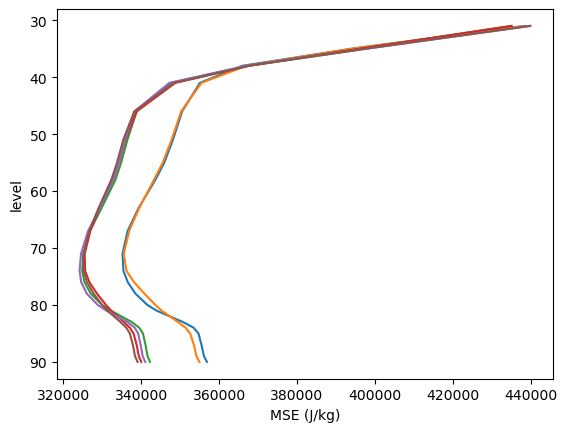

In [86]:

# ocean_mask_2deg_binary = xr.open_dataset(r'/work/mh1498/m301257/processed_data/ocean_mask_2deg.nc')

# ocean_mask_2deg_binary = ocean_mask_2deg_binary.rename_vars({'__xarray_dataarray_variable__': 'ocean_mask'})

mse_files = glob.glob(r"/work/mh1498/m301257/processed_data/mse*.nc")

mse_files 

for idx,file in enumerate(mse_files[:3]):
    print(idx,file)
    ds = xr.open_dataset(file).mse
    print(ds)
    mse_mean_west_pa = ds.mean(dim='time').sel(lat=slice(0,10),lon=slice(130,170))
    mse_mean_east_pa = ds.mean(dim='time').sel(lat=slice(5,10),lon=slice(180,180+70))
    # plt.figure(figsize=(10,5))
    # ds.mean(['time','level']).plot.contourf(cmap='viridis',levels=21)
    mse_mean_west_pa.mean(['lat','lon']).plot(y='level')
    mse_mean_east_pa.mean(['lat','lon']).plot(y='level')
    plt.gca().invert_yaxis()  # 反转y轴，使高压在下，低压在上
    # plt.ylabel('Pressure (hPa)')
    plt.xlabel('MSE (J/kg)')
    

In [87]:

# ocean_mask_2deg_binary = xr.open_dataset(r'/work/mh1498/m301257/processed_data/ocean_mask_2deg.nc')

# ocean_mask_2deg_binary = ocean_mask_2deg_binary.rename_vars({'__xarray_dataarray_variable__': 'ocean_mask'})

# ========== MSE垂直平流计算 ==========
# 垂直MSE平流 = -ω * ∂h/∂p
# 其中：
#   - ω (omega): 气压坐标垂直速度 (Pa/s)
#   - h: MSE湿静能 (J/kg)
#   - p: 气压 (Pa)

# ⚠️ 关键修复：确保MSE和omega文件正确配对
# 使用字典来确保实验之间的对应关系
experiments_data = {
    "cntl": {
        "mse": "/work/mh1498/m301257/processed_data/mse_cntl.nc",
        "omega": "/work/mh1498/m301257/omega_cntl_layers/wa_all_levels.nc", 
    },
    "p4k": {
        "mse": "/work/mh1498/m301257/processed_data/mse_p4k.nc",
        "omega": "/work/mh1498/m301257/omega_p4k_layers/wa_all_levels.nc",
    },
    "4co2": {
        "mse": "/work/mh1498/m301257/processed_data/mse_4co2.nc",
        "omega": "/work/mh1498/m301257/omega_4co2_layers/wa_all_levels.nc",
    }
}

print("="*70)
print("🔄 计算MSE垂直平流: -ω × ∂h/∂p")
print("="*70)


wdhdp = {}

for idx, (exp_name, paths) in enumerate(experiments_data.items(), 1):
    print(f"\n[{idx}/3] 处理实验: {exp_name.upper()}")
    
    # 加载MSE数据
    mse_file = paths["mse"]
    print(f"   MSE文件: {os.path.basename(mse_file)}")
    
    mse_ds = xr.open_dataset(mse_file)
    mse = mse_ds.mse
    print(f"   MSE shape: {mse.shape}, dims: {mse.dims}")
    
    # 检查level坐标（应该是压强，单位hPa）
    if 'level' in mse.coords:
        print(f"   Level (pressure) range: {mse.level.min().values:.1f} - {mse.level.max().values:.1f} hPa")
        pressure = mse.level * 100  # 转换为 Pa
    else:
        print(f"   ⚠️ 警告: 未找到level坐标!")
        continue
    
    # 计算 ∂h/∂p (MSE对压强的导数)
    # differentiate会自动使用坐标值进行求导
    dh_dp = mse.differentiate('level') / 100  # 除以100是因为level单位是hPa，要转为Pa
    print(f"   ∂h/∂p shape: {dh_dp.shape}")
    print(f"   ∂h/∂p range: {float(dh_dp.min()):.2e} - {float(dh_dp.max()):.2e} J/(kg·Pa)")
    
    # 加载omega数据（确保与MSE文件对应）
    omega_file = paths["omega"]
    print(f"   Omega文件: {os.path.basename(omega_file)}")
    
    omega_ds = xr.open_dataset(omega_file)
    
    # 获取omega变量（可能是'wap', 'omega', 或'wa'）
    if 'wap' in omega_ds:
        omega = omega_ds.wap
        print(f"   使用变量: wap (标准omega变量)")
    elif 'omega' in omega_ds:
        omega = omega_ds.omega
        print(f"   使用变量: omega")
    elif 'wa' in omega_ds:
        omega = omega_ds.wa
        print(f"   使用变量: wa (需要确认单位是Pa/s)")
    else:
        print(f"   ⚠️ 警告: 未找到omega/wap/wa变量，可用变量: {list(omega_ds.data_vars)}")
        continue
    
    print(f"   Omega shape: {omega.shape}, dims: {omega.dims}")
    
    # 统一坐标名称
    if 'level_full' in omega.dims:
        omega = omega.rename({'level_full': 'level'})
    
    # 调整维度顺序
    omega = omega.transpose('time', 'level', 'lat', 'lon')
    
    # 计算垂直MSE平流: -ω × ∂h/∂p
    # 负号表示omega>0（下沉）时，如果∂h/∂p<0（MSE随高度减小），则平流为正（加热）
    vertical_mse_advection = -omega * dh_dp
    print(f"   垂直平流 shape: {vertical_mse_advection.shape}")
    
    # 垂直积分（从地表到大气顶）
    # 注意：需要对压强积分，单位会变为 W/m²
    vertical_mse_transport = vertical_mse_advection.integrate('level') * 100  # 乘100因为level是hPa
    print(f"   垂直输送 shape: {vertical_mse_transport.shape}")
    print(f"   垂直输送 range: {float(vertical_mse_transport.min()):.2f} - {float(vertical_mse_transport.max()):.2f} W/m²")
    wdhdp[exp_name] = vertical_mse_transport
    # 绘图



🔄 计算MSE垂直平流: -ω × ∂h/∂p

[1/3] 处理实验: CNTL
   MSE文件: mse_cntl.nc
   MSE shape: (5114, 22, 15, 180), dims: ('time', 'level', 'lat', 'lon')
   Level (pressure) range: 31.0 - 90.0 hPa
   ∂h/∂p shape: (5114, 22, 15, 180)
   ∂h/∂p range: -1.60e+02 - 1.53e+02 J/(kg·Pa)
   Omega文件: wa_all_levels.nc
   ∂h/∂p shape: (5114, 22, 15, 180)
   ∂h/∂p range: -1.60e+02 - 1.53e+02 J/(kg·Pa)
   Omega文件: wa_all_levels.nc
   使用变量: wa (需要确认单位是Pa/s)
   Omega shape: (22, 5114, 15, 180), dims: ('level', 'time', 'lat', 'lon')
   使用变量: wa (需要确认单位是Pa/s)
   Omega shape: (22, 5114, 15, 180), dims: ('level', 'time', 'lat', 'lon')
   垂直平流 shape: (5114, 22, 15, 180)
   垂直平流 shape: (5114, 22, 15, 180)
   垂直输送 shape: (5114, 15, 180)
   垂直输送 range: -5707.35 - 11425.14 W/m²

[2/3] 处理实验: P4K
   MSE文件: mse_p4k.nc
   MSE shape: (5114, 22, 15, 180), dims: ('time', 'level', 'lat', 'lon')
   Level (pressure) range: 31.0 - 90.0 hPa
   垂直输送 shape: (5114, 15, 180)
   垂直输送 range: -5707.35 - 11425.14 W/m²

[2/3] 处理实验: P4K
   MSE文件: m

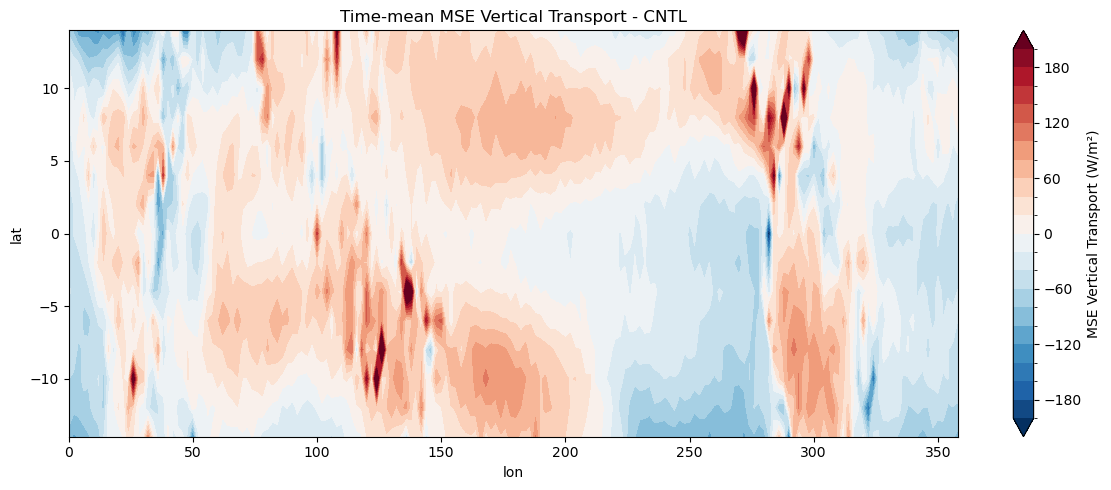

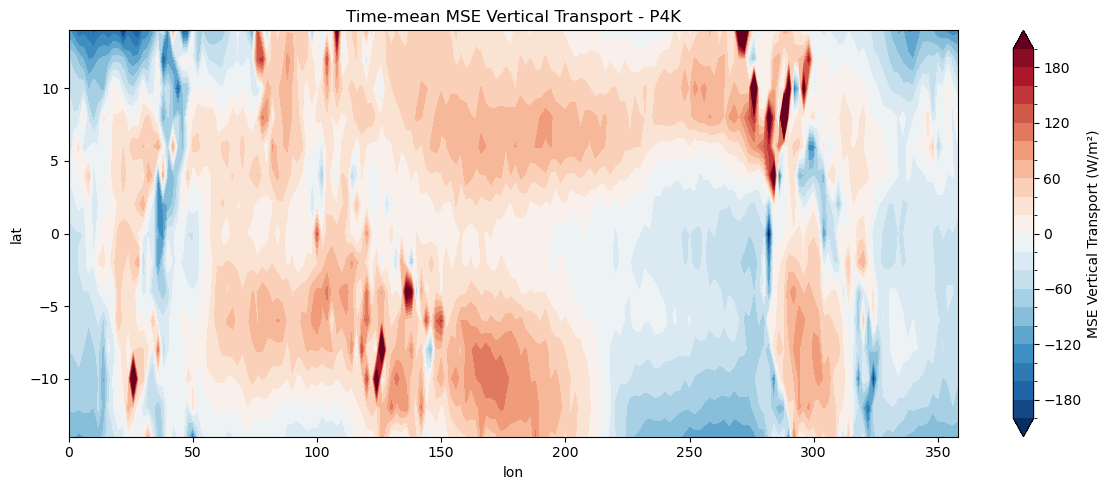

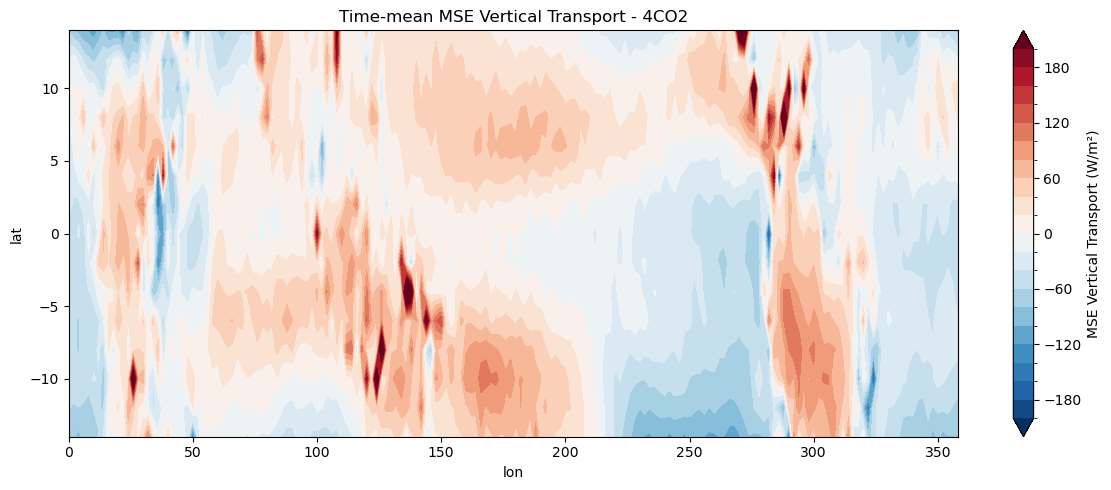


✅ MSE垂直平流计算完成!


In [89]:
# ========== 创建海洋掩膜（如果不存在）==========
ocean_mask_path = '/work/mh1498/m301257/processed_data/ocean_mask_2deg.nc'

if not os.path.exists(ocean_mask_path):
    print("="*70)
    print("🌊 创建海洋掩膜...")
    print("="*70)
    
    # 定义2度网格
    lats = np.arange(-14, 14.1, 2.0)
    lons = np.arange(0, 360, 2.0)
    
    # 使用globe.is_ocean()创建掩膜
    ocean_mask_data = np.zeros((len(lats), len(lons)))
    
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            ocean_mask_data[i, j] = 1 if globe.is_ocean(lat, lon) else 0
    
    # 创建DataArray
    ocean_mask = xr.DataArray(
        ocean_mask_data,
        coords={'lat': lats, 'lon': lons},
        dims=['lat', 'lon'],
        name='ocean_mask'
    )
    
    # 保存
    ocean_mask.to_netcdf(ocean_mask_path)
    print(f"✅ 海洋掩膜已创建: {ocean_mask_path}")
    print(f"   形状: {ocean_mask.shape}")
    print(f"   海洋占比: {float(ocean_mask.mean())*100:.1f}%")
else:
    print(f"✅ 海洋掩膜已存在: {ocean_mask_path}")

✅ 海洋掩膜已存在: /work/mh1498/m301257/processed_data/ocean_mask_2deg.nc



🌊 加载海洋掩膜...
✅ 海洋掩膜加载成功: (15, 180)
   海洋区域占比: 77.4%

CNTL: 应用海洋掩膜


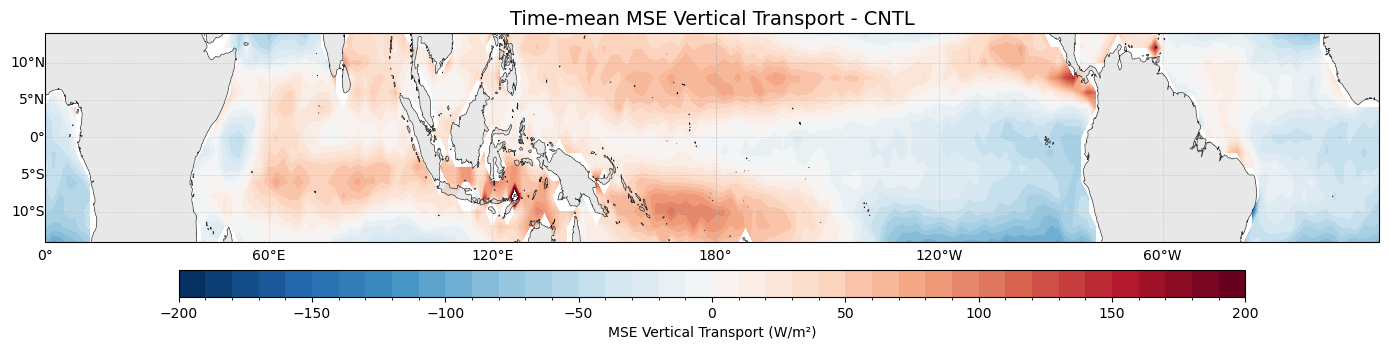

   海洋区域统计:
   Min: -168.36 W/m²
   Max: 349.34 W/m²
   Mean: 4.13 W/m²

P4K: 应用海洋掩膜


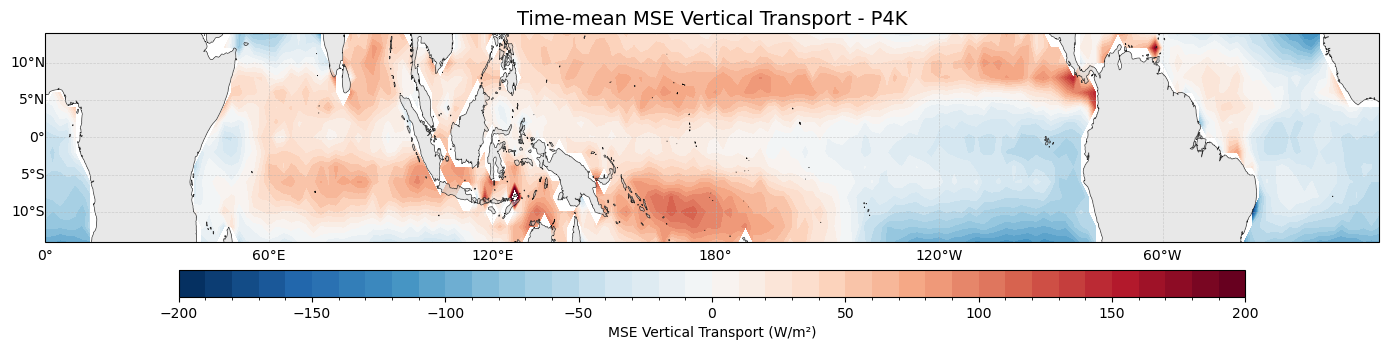

   海洋区域统计:
   Min: -215.19 W/m²
   Max: 369.64 W/m²
   Mean: 9.04 W/m²

4CO2: 应用海洋掩膜


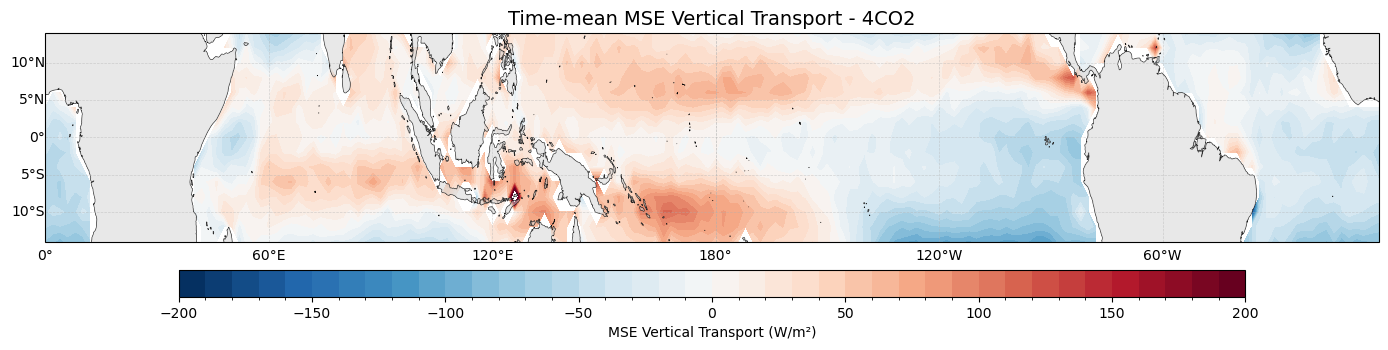

   海洋区域统计:
   Min: -184.25 W/m²
   Max: 342.26 W/m²
   Mean: 0.51 W/m²

✅ MSE垂直平流计算完成!


In [98]:
# ========== 加载海洋掩膜 ==========
print("\n🌊 加载海洋掩膜...")
ocean_mask_path = '/work/mh1498/m301257/processed_data/ocean_mask_2deg.nc'

if os.path.exists(ocean_mask_path):
    ocean_mask_ds = xr.open_dataset(ocean_mask_path)
    # 检查变量名
    if 'ocean_mask' in ocean_mask_ds:
        ocean_mask = ocean_mask_ds['ocean_mask']
    elif '__xarray_dataarray_variable__' in ocean_mask_ds:
        ocean_mask = ocean_mask_ds['__xarray_dataarray_variable__']
    else:
        # 如果是DataArray直接打开
        ocean_mask = xr.open_dataarray(ocean_mask_path)
    
    print(f"✅ 海洋掩膜加载成功: {ocean_mask.shape}")
    print(f"   海洋区域占比: {float(ocean_mask.mean())*100:.1f}%")
else:
    print(f"⚠️ 海洋掩膜文件不存在，将显示所有区域")
    ocean_mask = None

# ========== 绘制海洋区域的MSE垂直输送 ==========
for exp_name, vertical_mse_transport in wdhdp.items():
    
    # 时间平均
    data_mean = vertical_mse_transport.mean(dim='time')
    
    # 应用海洋掩膜（只显示海洋区域）
    if ocean_mask is not None:
        # 确保掩膜的维度与数据匹配
        if set(ocean_mask.dims) == set(data_mean.dims):
            data_ocean = data_mean.where(ocean_mask == 1)  # 只保留海洋区域（mask=1）
            print(f"\n{exp_name.upper()}: 应用海洋掩膜")
        else:
            print(f"\n{exp_name.upper()}: ⚠️ 掩膜维度不匹配，显示所有区域")
            data_ocean = data_mean
    else:
        data_ocean = data_mean
    
    # 绘图
    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(180))
    
    # 绘制数据（只有海洋区域有值，陆地为NaN会显示为空白）
    im = data_ocean.plot.contourf(
        ax=ax,
        cmap='RdBu_r', 
        levels=np.linspace(-200, 200, 41),
        cbar_kwargs={'label': 'MSE Vertical Transport (W/m²)', 'shrink': 0.8,
                     'aspect': 40,
                     'orientation': 'horizontal', 'pad': 0.05},
        extend = 'neither'  ,
        transform=ccrs.PlateCarree(),
        add_colorbar=True
    )
    
    # 添加海岸线和陆地
    ax.coastlines(linewidth=0.5, color='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5, zorder=2)
    ax.set_aspect(2)
    # 添加网格线
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    # 设置标题
    ax.set_title(f'Time-mean MSE Vertical Transport - {exp_name.upper()}', 
                 fontsize=14, )
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息（仅海洋区域）
    print(f"   海洋区域统计:")
    print(f"   Min: {float(data_ocean.min()):.2f} W/m²")
    print(f"   Max: {float(data_ocean.max()):.2f} W/m²")
    print(f"   Mean: {float(data_ocean.mean()):.2f} W/m²")

print("\n" + "="*70)
print("✅ MSE垂直平流计算完成!")
print("="*70)